In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url,sep=';')
print(df.head())
print(df.shape)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.2, random_state=42)

print("training samples: ", len(X_train))
print('testing samples', len(X_test))

training samples:  1279
testing samples 320


In [3]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train,y_train)

prediction = model.predict(X_test)
print(prediction[:20])

[5 5 5 5 6 5 5 5 6 6 7 5 6 5 6 6 5 6 7 5]


In [4]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, prediction)

print(accuracy)
print(classification_report(y_test,prediction))

0.659375
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.75      0.73       130
           6       0.63      0.69      0.66       132
           7       0.63      0.52      0.57        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, prediction, average='weighted',
                            zero_division=0)
recall = recall_score(y_test, prediction, average='weighted',
                            zero_division=0)
f1 = f1_score(y_test, prediction, average='weighted',
                            zero_division=0)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.659375
Precision: 0.6319815001258495
Recall   : 0.659375
F1 Score : 0.6442498546491976


In [6]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, prediction)

print(cm)

[[ 0  0  1  0  0  0]
 [ 0  0  7  3  0  0]
 [ 0  0 98 31  1  0]
 [ 0  1 31 91  8  1]
 [ 0  0  0 19 22  1]
 [ 0  0  0  1  4  0]]


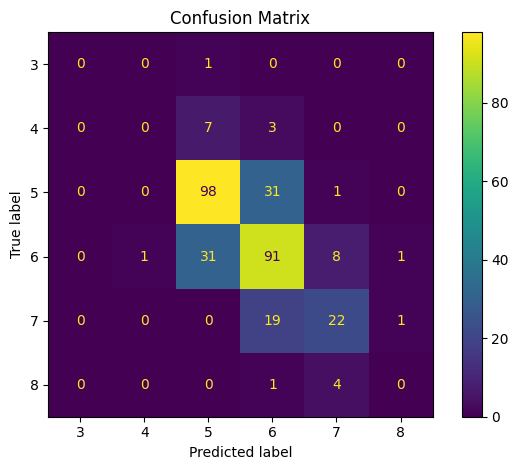

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)

disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig("confusion_matrix.png")

plt.show()

In [8]:
feature_importance = pd.Series(model.feature_importances_,
                               index = X.columns)

print(feature_importance.sort_values(ascending=False))

alcohol                 0.148987
sulphates               0.115690
total sulfur dioxide    0.102300
volatile acidity        0.096902
density                 0.094191
chlorides               0.080256
pH                      0.076720
fixed acidity           0.075106
citric acid             0.071624
residual sugar          0.071444
free sulfur dioxide     0.066778
dtype: float64


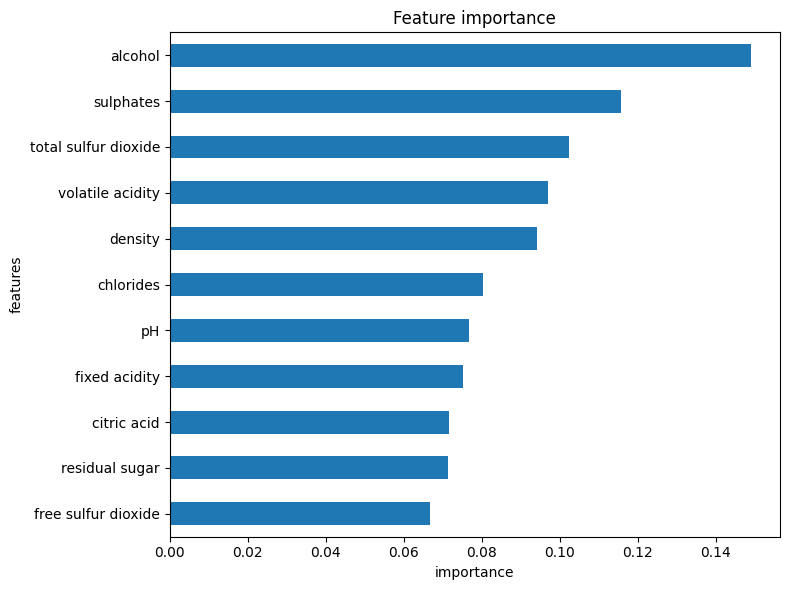

In [9]:
feature_importance.sort_values().plot(kind='barh', figsize=(8,6))

plt.title('Feature importance')
plt.xlabel('importance')
plt.ylabel('features')

plt.tight_layout()
plt.savefig("feature_importance.png")

plt.show()

In [10]:
report_data = {
    "model": "Random Forest Classifier",
    "trees": 100,
    "training_samples": len(X_train),
    "testing_samples": len(X_test),
    "features": len(X.columns),
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1
}

print(report_data)

{'model': 'Random Forest Classifier', 'trees': 100, 'training_samples': 1279, 'testing_samples': 320, 'features': 11, 'accuracy': 0.659375, 'precision': 0.6319815001258495, 'recall': 0.659375, 'f1_score': 0.6442498546491976}


In [11]:
pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.0 MB/s eta 0:00:00


In [37]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    Image
)

from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib import colors

doc = SimpleDocTemplate(
    "ML_Model_Evaluation_Report.pdf",
    rightMargin=50,
    leftMargin=50,
    topMargin=50,
    bottomMargin=50
)

styles = getSampleStyleSheet()

story = []

title_style = ParagraphStyle(
    "ReportTitle",
    parent=styles["Title"],
    alignment=TA_CENTER,
    fontSize=22,
    spaceAfter=20
)

story.append(
    Paragraph(
        "Machine Learning Model Evaluation Report",
        title_style
    )
)

story.append(
    Paragraph(
        "Wine Quality Classification using Random Forest",
        styles["Normal"]
    )
)

story.append(Spacer(1, 20))

story.append(
    Paragraph(
        "1. Model Overview",
        styles["Heading2"]
    )
)

overview_data = [
    ["Property", "Value"],
    ["Model", report_data["model"]],
    ["Number of Trees", report_data["trees"]],
    ["Training Samples", report_data["training_samples"]],
    ["Testing Samples", report_data["testing_samples"]],
    ["Number of Features", report_data["features"]]
]

overview_table = Table(
    overview_data,
    colWidths=[200, 250]
)

overview_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
        ("TOPPADDING", (0, 0), (-1, -1), 7),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 7),
    ])
)

story.append(overview_table)

story.append(Spacer(1, 20))

story.append(
    Paragraph(
        "2. Model Performance",
        styles["Heading2"]
    )
)

metrics_data = [
    ["Metric", "Score"],
    ["Accuracy", f"{report_data['accuracy']:.2%}"],
    ["Precision", f"{report_data['precision']:.2%}"],
    ["Recall", f"{report_data['recall']:.2%}"],
    ["F1 Score", f"{report_data['f1_score']:.2%}"]
]

metrics_table = Table(
    metrics_data,
    colWidths=[200, 250]
)

metrics_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("ALIGN", (1, 1), (1, -1), "CENTER"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
        ("TOPPADDING", (0, 0), (-1, -1), 7),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 7),
    ])
)

story.append(metrics_table)

story.append(Spacer(1, 20))

story.append(
    Paragraph(
        "3. Understanding the Metrics",
        styles["Heading2"]
    )
)

metric_explanations = [
    ["Metric", "Meaning"],
    [
        "Accuracy",
        "Percentage of all test predictions that were correct."
    ],
    [
        "Precision",
        "Among predictions made for a class, how often the prediction was correct."
    ],
    [
        "Recall",
        "Among samples that actually belong to a class, how many were correctly identified."
    ],
    [
        "F1 Score",
        "A balance between precision and recall. It is useful when both types of errors matter."
    ],
    [
        "Confusion Matrix",
        "Shows how actual classes were classified into predicted classes."
    ]
]

explanation_table = Table(
     metric_explanations,
    colWidths=[120, 410]
)

explanation_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
        ("TOPPADDING", (0, 0), (-1, -1), 7),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 7),
    ])
)

story.append(explanation_table)

story.append(Spacer(1, 25))

story.append(
    Paragraph(
        "4. Confusion Matrix",
        styles["Heading2"]
    )
)

story.append(
    Paragraph(
        "The confusion matrix shows the relationship between the actual "
        "wine-quality classes and the classes predicted by the model.",
        styles["Normal"]
    )
)

story.append(Spacer(1, 10))

confusion_image = Image(
    "confusion_matrix.png",
    width=400,
    height=350
)

story.append(confusion_image)

story.append(Spacer(1, 20))

story.append(
    Paragraph(
        "5. Feature Importance",
        styles["Heading2"]
    )
)

story.append(
    Paragraph(
        "Feature importance indicates the relative contribution of "
        "features to the Random Forest's impurity-based splitting process.",
        styles["Normal"]
    )
)

story.append(Spacer(1, 10))

importance_image = Image(
    "feature_importance.png",
    width=450,
    height=350
)

story.append(importance_image)

In [38]:
if accuracy >= 0.80:
    performance_text = "The model achieved strong overall predictive performance."
elif accuracy >= 0.60:
    performance_text = "The model achieved moderate overall predictive performance."
else:
    performance_text = "The model achieved relatively low overall predictive performance."

findings = (
    f"The Random Forest model achieved an accuracy of {accuracy:.2%} "
    f"and a weighted F1 score of {f1:.2%}. "
    f"{performance_text}"
)

print(findings)


The Random Forest model achieved an accuracy of 65.94% and a weighted F1 score of 64.42%. The model achieved moderate overall predictive performance.


In [39]:
story.append(Spacer(1, 20))

story.append(
    Paragraph(
        "6. Model Findings",
        styles["Heading2"]
    )
)

story.append(
    Paragraph(
        findings,
        styles["Normal"]
    )
)

story.append(Spacer(1, 15))

story.append(
    Paragraph(
        "The model performs better on the more frequently represented "
        "quality classes and has difficulty identifying rare classes. "
        "This indicates that class distribution is an important "
        "consideration when interpreting the results.",
        styles["Normal"]
    )
)

In [40]:
def add_page_number(canvas, doc):
  canvas.saveState()
  canvas.setFont("Helvetica", 9)
  canvas.drawRightString(550, 30, f"Page {doc.page}")
  canva.restoreState()

#add date

In [41]:
from datetime import datetime

report_date = datetime.now().strftime("%d %B %Y")

print(report_date)

story.append(Spacer(1,50))

story.append(Paragraph(f"Generated on: {report_date}", styles["Normal"]))

23 August 2026


In [42]:
doc.build(
    story,
    onFirstPage=add_page_number,
    onLaterPages=add_page_number
)